In [2]:
import pandas as pd

In [3]:
jobs = pd.read_csv(r"C:\Users\Mahmoud Gobran\00_Ironhack\Projects\the-professor-project-1-ironhack\MG\salary_dataset.csv")
jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           607 non-null    int64 
 1   experience_level    607 non-null    object
 2   employment_type     607 non-null    object
 3   job_title           607 non-null    object
 4   salary              607 non-null    int64 
 5   salary_currency     607 non-null    object
 6   salary_in_usd       607 non-null    int64 
 7   employee_residence  607 non-null    object
 8   remote_ratio        607 non-null    int64 
 9   company_location    607 non-null    object
 10  company_size        607 non-null    object
dtypes: int64(4), object(7)
memory usage: 52.3+ KB


In [4]:
jobs

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Developer,260000,USD,260000,JP,0,JP,S
2,2020,SE,FT,Data Engineer,85000,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Data Analyst,20000,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Developer,150000,USD,150000,US,50,US,L
...,...,...,...,...,...,...,...,...,...,...,...
602,2022,SE,FT,Data Engineer,154000,USD,154000,US,100,US,M
603,2022,SE,FT,Data Engineer,126000,USD,126000,US,100,US,M
604,2022,SE,FT,Data Analyst,129000,USD,129000,US,0,US,M
605,2022,SE,FT,Data Analyst,150000,USD,150000,US,100,US,M


In [5]:
total_duplicates = jobs.duplicated().sum()
print(f'Total fully duplicated rows: {total_duplicates}')


Total fully duplicated rows: 45


1. Change data type
(done)

In [6]:
# Keep relevant columns, avoid non-relevant ones
columns_to_keep = [
    'work_year', 'job_title', 'salary_in_usd', 'remote_ratio', 'company_location', 
    
]
jobs_cleaned = jobs[columns_to_keep].copy()

#rename columns
jobs_cleaned.rename(columns={
    'work_year': 'date',
    'company_location': 'country',
    'remote_ratio': 'work_mode',
    
}, inplace=True)

    # 4. Add a new column named 'skills' to the end
jobs_cleaned['skills'] = ''

jobs_cleaned['work_mode'] = jobs_cleaned['work_mode'].map({
    0: 'on_site',
    50: 'hybrid',
    100: 'remote'
})


In [7]:
jobs_cleaned

,date,job_title,salary_in_usd,work_mode,country,skills
0,2020,Data Scientist,79833,on_site,DE,
1,2020,Machine Learning Developer,260000,on_site,JP,
2,2020,Data Engineer,109024,hybrid,GB,
3,2020,Data Analyst,20000,on_site,HN,
4,2020,Machine Learning Developer,150000,hybrid,US,
...,...,...,...,...,...,...
602,2022,Data Engineer,154000,remote,US,
603,2022,Data Engineer,126000,remote,US,
604,2022,Data Analyst,129000,on_site,US,
605,2022,Data Analyst,150000,remote,US,


In [8]:
unique_job_titles = jobs_cleaned['job_title'].unique()
print(unique_job_titles)

['Data Scientist' 'Machine Learning Developer' 'Data Engineer'
 'Data Analyst']


In [9]:
# fill the skills column based on the job_title, use a mapping dictionary 

skills_map = {
    'Data Scientist': [
        'Python', 'R',
        'Statistics',
        'Machine learning',
        'Data cleaning',
        'SQL',
        'Visualization (e.g. Tableau)',
        'Big data (e.g. Spark)',
        'Model validation',
        'Communication',
        'Domain knowledge'
    ],
    'Machine Learning Developer': [
        'Python', 'C++',
        'TensorFlow', 'PyTorch',
        'ML algorithms',
        'Data pipelines',
        'Deployment',
        'Cloud (AWS, GCP)',
        'Git',
        'Math',
        'Experiment tracking',
        'Software practices'
    ],
    'Data Engineer': [
        'Python', 'Java', 'Scala',
        'SQL', 'NoSQL',
        'ETL', 'pipelines',
        'Spark', 'Kafka',
        'Airflow',
        'Cloud platforms',
        'Data modeling',
        'Docker', 'Kubernetes',
        'APIs',
        'Linux'
    ],
    'Data Analyst': [
        'SQL',
        'Excel',
        'Python', 'R',
        'Tableau', 'Power BI',
        'Statistics',
        'Cleaning data',
        'Reporting',
        'Communication',
        'Business insight',
        'Critical thinking'
    ]
}

jobs_cleaned['skills'] = jobs_cleaned['job_title'].map(skills_map)


print(jobs_cleaned[['job_title', 'skills']].head(10))

jobs_cleaned.loc[0]


#jobs_cleaned.loc[0, 'skills']
# Output: ['Python', 'R', 'Statistics', ...]



                    job_title  \
0              Data Scientist   
1  Machine Learning Developer   
2               Data Engineer   
3                Data Analyst   
4  Machine Learning Developer   
5                Data Analyst   
6              Data Scientist   
7              Data Scientist   
8                Data Analyst   
9               Data Engineer   

                                              skills  
0  [Python, R, Statistics, Machine learning, Data...  
1  [Python, C++, TensorFlow, PyTorch, ML algorith...  
2  [Python, Java, Scala, SQL, NoSQL, ETL, pipelin...  
3  [SQL, Excel, Python, R, Tableau, Power BI, Sta...  
4  [Python, C++, TensorFlow, PyTorch, ML algorith...  
5  [SQL, Excel, Python, R, Tableau, Power BI, Sta...  
6  [Python, R, Statistics, Machine learning, Data...  
7  [Python, R, Statistics, Machine learning, Data...  
8  [SQL, Excel, Python, R, Tableau, Power BI, Sta...  
9  [Python, Java, Scala, SQL, NoSQL, ETL, pipelin...  


date                                                          2020
job_title                                           Data Scientist
salary_in_usd                                                79833
work_mode                                                  on_site
country                                                         DE
skills           [Python, R, Statistics, Machine learning, Data...
Name: 0, dtype: object

In [10]:
#Example that give all jobs that list 'SQL' as a skill.
jobs_cleaned[jobs_cleaned['skills'].apply(lambda x: 'SQL' in x)]


,date,job_title,salary_in_usd,work_mode,country,skills
0,2020,Data Scientist,79833,on_site,DE,"[Python, R, Statistics, Machine learning, Data..."
2,2020,Data Engineer,109024,hybrid,GB,"[Python, Java, Scala, SQL, NoSQL, ETL, pipelin..."
3,2020,Data Analyst,20000,on_site,HN,"[SQL, Excel, Python, R, Tableau, Power BI, Sta..."
5,2020,Data Analyst,72000,remote,US,"[SQL, Excel, Python, R, Tableau, Power BI, Sta..."
6,2020,Data Scientist,190000,remote,US,"[Python, R, Statistics, Machine learning, Data..."
...,...,...,...,...,...,...
602,2022,Data Engineer,154000,remote,US,"[Python, Java, Scala, SQL, NoSQL, ETL, pipelin..."
603,2022,Data Engineer,126000,remote,US,"[Python, Java, Scala, SQL, NoSQL, ETL, pipelin..."
604,2022,Data Analyst,129000,on_site,US,"[SQL, Excel, Python, R, Tableau, Power BI, Sta..."
605,2022,Data Analyst,150000,remote,US,"[SQL, Excel, Python, R, Tableau, Power BI, Sta..."


In [11]:
jobs_cleaned

,date,job_title,salary_in_usd,work_mode,country,skills
0,2020,Data Scientist,79833,on_site,DE,"[Python, R, Statistics, Machine learning, Data..."
1,2020,Machine Learning Developer,260000,on_site,JP,"[Python, C++, TensorFlow, PyTorch, ML algorith..."
2,2020,Data Engineer,109024,hybrid,GB,"[Python, Java, Scala, SQL, NoSQL, ETL, pipelin..."
3,2020,Data Analyst,20000,on_site,HN,"[SQL, Excel, Python, R, Tableau, Power BI, Sta..."
4,2020,Machine Learning Developer,150000,hybrid,US,"[Python, C++, TensorFlow, PyTorch, ML algorith..."
...,...,...,...,...,...,...
602,2022,Data Engineer,154000,remote,US,"[Python, Java, Scala, SQL, NoSQL, ETL, pipelin..."
603,2022,Data Engineer,126000,remote,US,"[Python, Java, Scala, SQL, NoSQL, ETL, pipelin..."
604,2022,Data Analyst,129000,on_site,US,"[SQL, Excel, Python, R, Tableau, Power BI, Sta..."
605,2022,Data Analyst,150000,remote,US,"[SQL, Excel, Python, R, Tableau, Power BI, Sta..."


In [12]:
#save the cleaned and transformed data to a new DataFrame.  final_jobs contains: Renamed columns, New skills column (as lists), Mapped work_mode values

final_jobs = jobs_cleaned.copy()

final_jobs.head()

# save it for future use
final_jobs.to_csv('final_jobs.csv', index=False)



2. Drop Duplicate

In [13]:
duplicate_count = final_jobs.duplicated(subset=['date', 'job_title', 'salary_in_usd', 'work_mode', 'country']).sum()
print(f'Duplicates found: {duplicate_count}')


Duplicates found: 67


In [14]:
duplicates = final_jobs[final_jobs.duplicated(subset=['date', 'job_title', 'salary_in_usd', 'work_mode', 'country'], keep=False)]

print(duplicates.sort_values(by=['date', 'job_title', 'salary_in_usd']))


     date                   job_title  salary_in_usd work_mode country  \
48   2020              Data Scientist         105000    remote      US   
68   2020              Data Scientist         105000    remote      US   
79   2021                Data Analyst          80000    remote      US   
89   2021                Data Analyst          80000    remote      US   
241  2021                Data Analyst          80000    remote      US   
..    ...                         ...            ...       ...     ...   
485  2022  Machine Learning Developer         120000    remote      US   
372  2022  Machine Learning Developer         164996   on_site      US   
439  2022  Machine Learning Developer         164996   on_site      US   
371  2022  Machine Learning Developer         189650   on_site      US   
438  2022  Machine Learning Developer         189650   on_site      US   

                                                skills  
48   [Python, R, Statistics, Machine learning, Data...

In [15]:
final_jobs = final_jobs.drop_duplicates(subset=['date', 'job_title', 'salary_in_usd', 'work_mode', 'country'])


In [18]:
for col in final_jobs.columns:
    if final_jobs[col].apply(lambda x: isinstance(x, list)).any():
        final_jobs[col] = final_jobs[col].apply(str)

final_jobs_unique = final_jobs.drop_duplicates()


In [ ]:
jobs_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 540 entries, 0 to 605
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   date           540 non-null    int64 
 1   job_title      540 non-null    object
 2   salary_in_usd  540 non-null    int64 
 3   remote_ratio   540 non-null    int64 
 4   country        540 non-null    object
 5   skills         540 non-null    object
dtypes: int64(3), object(3)
memory usage: 29.5+ KB


In [20]:
jobs_cleaned

,date,job_title,salary_in_usd,work_mode,country,skills
0,2020,Data Scientist,79833,on_site,DE,"[Python, R, Statistics, Machine learning, Data..."
1,2020,Machine Learning Developer,260000,on_site,JP,"[Python, C++, TensorFlow, PyTorch, ML algorith..."
2,2020,Data Engineer,109024,hybrid,GB,"[Python, Java, Scala, SQL, NoSQL, ETL, pipelin..."
3,2020,Data Analyst,20000,on_site,HN,"[SQL, Excel, Python, R, Tableau, Power BI, Sta..."
4,2020,Machine Learning Developer,150000,hybrid,US,"[Python, C++, TensorFlow, PyTorch, ML algorith..."
...,...,...,...,...,...,...
602,2022,Data Engineer,154000,remote,US,"[Python, Java, Scala, SQL, NoSQL, ETL, pipelin..."
603,2022,Data Engineer,126000,remote,US,"[Python, Java, Scala, SQL, NoSQL, ETL, pipelin..."
604,2022,Data Analyst,129000,on_site,US,"[SQL, Excel, Python, R, Tableau, Power BI, Sta..."
605,2022,Data Analyst,150000,remote,US,"[SQL, Excel, Python, R, Tableau, Power BI, Sta..."


In [19]:
final_jobs_unique

,date,job_title,salary_in_usd,work_mode,country,skills
0,2020,Data Scientist,79833,on_site,DE,"['Python', 'R', 'Statistics', 'Machine learnin..."
1,2020,Machine Learning Developer,260000,on_site,JP,"['Python', 'C++', 'TensorFlow', 'PyTorch', 'ML..."
2,2020,Data Engineer,109024,hybrid,GB,"['Python', 'Java', 'Scala', 'SQL', 'NoSQL', 'E..."
3,2020,Data Analyst,20000,on_site,HN,"['SQL', 'Excel', 'Python', 'R', 'Tableau', 'Po..."
4,2020,Machine Learning Developer,150000,hybrid,US,"['Python', 'C++', 'TensorFlow', 'PyTorch', 'ML..."
...,...,...,...,...,...,...
601,2022,Data Analyst,52000,on_site,CA,"['SQL', 'Excel', 'Python', 'R', 'Tableau', 'Po..."
602,2022,Data Engineer,154000,remote,US,"['Python', 'Java', 'Scala', 'SQL', 'NoSQL', 'E..."
603,2022,Data Engineer,126000,remote,US,"['Python', 'Java', 'Scala', 'SQL', 'NoSQL', 'E..."
604,2022,Data Analyst,129000,on_site,US,"['SQL', 'Excel', 'Python', 'R', 'Tableau', 'Po..."


3. Handle Missing Data

4. Remove Outliers

<Axes: >

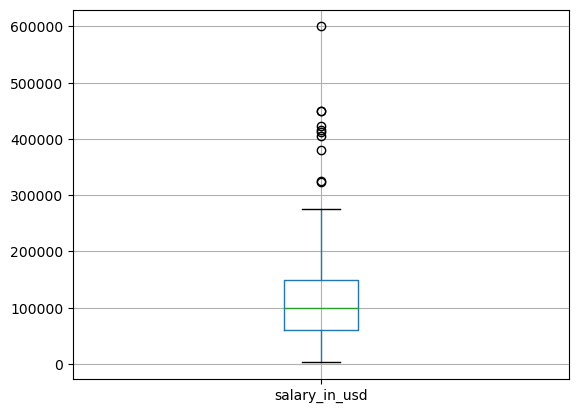

In [21]:
#Before
final_jobs_unique.boxplot(column='salary_in_usd')

In [22]:
final_jobs_unique['salary_in_usd'].describe()

count       540.000000
mean     109778.790741
std       73121.834745
min        2859.000000
25%       59825.750000
50%       99851.500000
75%      150000.000000
max      600000.000000
Name: salary_in_usd, dtype: float64

In [24]:
q1 = final_jobs_unique['salary_in_usd'].quantile(0.25)
q3 = final_jobs_unique['salary_in_usd'].quantile(0.75)
upper_limit = q3 +  1.5 * (q3-q1)
lower_limit = q1 -  1.5 * (q3-q1)

In [25]:
final_jobs_unique = final_jobs_unique[final_jobs_unique['salary_in_usd'] > lower_limit]
final_jobs_unique = final_jobs_unique[final_jobs_unique['salary_in_usd'] < upper_limit]
final_jobs_unique['salary_in_usd'].describe()

count       530.000000
mean     103953.862264
std       59241.001551
min        2859.000000
25%       59102.000000
50%       98579.000000
75%      144640.500000
max      276000.000000
Name: salary_in_usd, dtype: float64

In [29]:
#After
final_jobs_unique.boxplot(column='salary_in_usd')

<Axes: >

In [27]:
final_jobs_unique.info()

<class 'pandas.core.frame.DataFrame'>
Index: 530 entries, 0 to 605
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   date           530 non-null    int64 
 1   job_title      530 non-null    object
 2   salary_in_usd  530 non-null    int64 
 3   work_mode      530 non-null    object
 4   country        530 non-null    object
 5   skills         530 non-null    object
dtypes: int64(2), object(4)
memory usage: 29.0+ KB


In [ ]:
562-552

10

In [ ]:
10/562

0.017793594306049824

In [28]:
final_jobs_unique

,date,job_title,salary_in_usd,work_mode,country,skills
0,2020,Data Scientist,79833,on_site,DE,"['Python', 'R', 'Statistics', 'Machine learnin..."
1,2020,Machine Learning Developer,260000,on_site,JP,"['Python', 'C++', 'TensorFlow', 'PyTorch', 'ML..."
2,2020,Data Engineer,109024,hybrid,GB,"['Python', 'Java', 'Scala', 'SQL', 'NoSQL', 'E..."
3,2020,Data Analyst,20000,on_site,HN,"['SQL', 'Excel', 'Python', 'R', 'Tableau', 'Po..."
4,2020,Machine Learning Developer,150000,hybrid,US,"['Python', 'C++', 'TensorFlow', 'PyTorch', 'ML..."
...,...,...,...,...,...,...
601,2022,Data Analyst,52000,on_site,CA,"['SQL', 'Excel', 'Python', 'R', 'Tableau', 'Po..."
602,2022,Data Engineer,154000,remote,US,"['Python', 'Java', 'Scala', 'SQL', 'NoSQL', 'E..."
603,2022,Data Engineer,126000,remote,US,"['Python', 'Java', 'Scala', 'SQL', 'NoSQL', 'E..."
604,2022,Data Analyst,129000,on_site,US,"['SQL', 'Excel', 'Python', 'R', 'Tableau', 'Po..."


In [ ]:
salary.to_csv('salary-dataset.csv')

from google.colab import files
files.download('salary-dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>